In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('All imports successful!')

All imports successful!


In [6]:
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv', index_col=0)
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["date"].min()} → {df["date"].max()}')
df.head()

Shape: (1407328, 5)
Columns: ['headline', 'url', 'publisher', 'date', 'stock']
Date range: 2009-02-14 00:00:00+00:00 → 2020-06-11 21:12:35+00:00


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


In [8]:
# Missing values and basic info
print('--- Missing Values ---')
print(df.isnull().sum())
print()
print(f'Unique publishers: {df["publisher"].nunique()}')
print(f'Unique stocks: {df["stock"].nunique()}')
print(f'Total articles: {len(df)}')

--- Missing Values ---
headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64

Unique publishers: 1034
Unique stocks: 6204
Total articles: 1407328


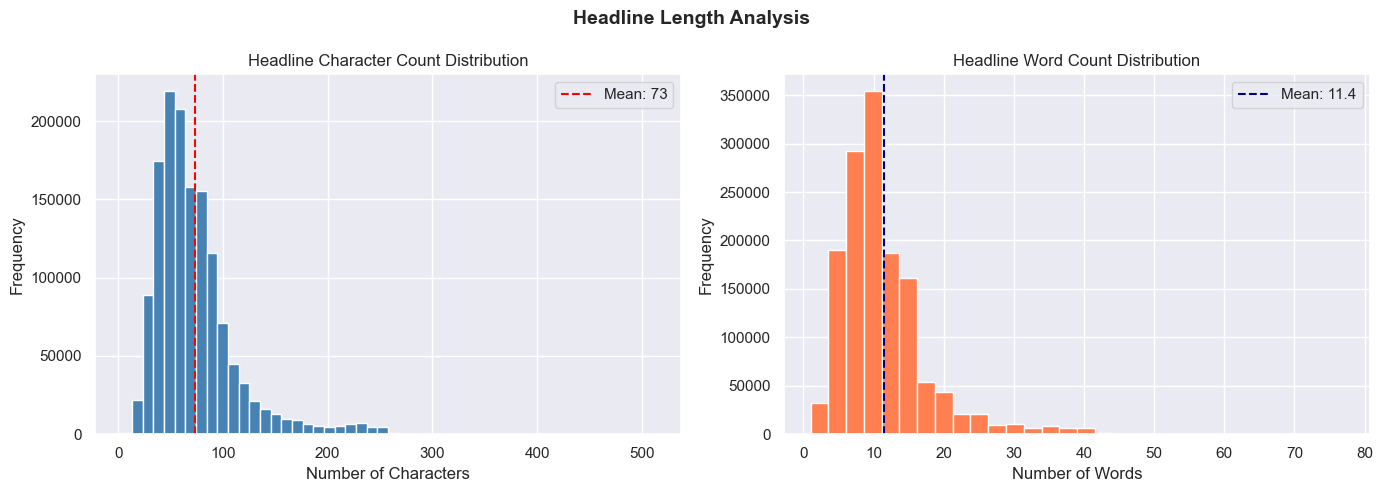

count    1407328.00
mean          73.12
std           40.74
min            3.00
25%           47.00
50%           64.00
75%           87.00
max          512.00
Name: headline_length, dtype: float64


In [9]:
# Headline length distribution
df['headline_length'] = df['headline'].str.len()
df['word_count'] = df['headline'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['headline_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['headline_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["headline_length"].mean():.0f}')
axes[0].set_title('Headline Character Count Distribution')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['word_count'], bins=30, color='coral', edgecolor='white')
axes[1].axvline(df['word_count'].mean(), color='navy', linestyle='--', label=f'Mean: {df["word_count"].mean():.1f}')
axes[1].set_title('Headline Word Count Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Headline Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(df['headline_length'].describe().round(2))

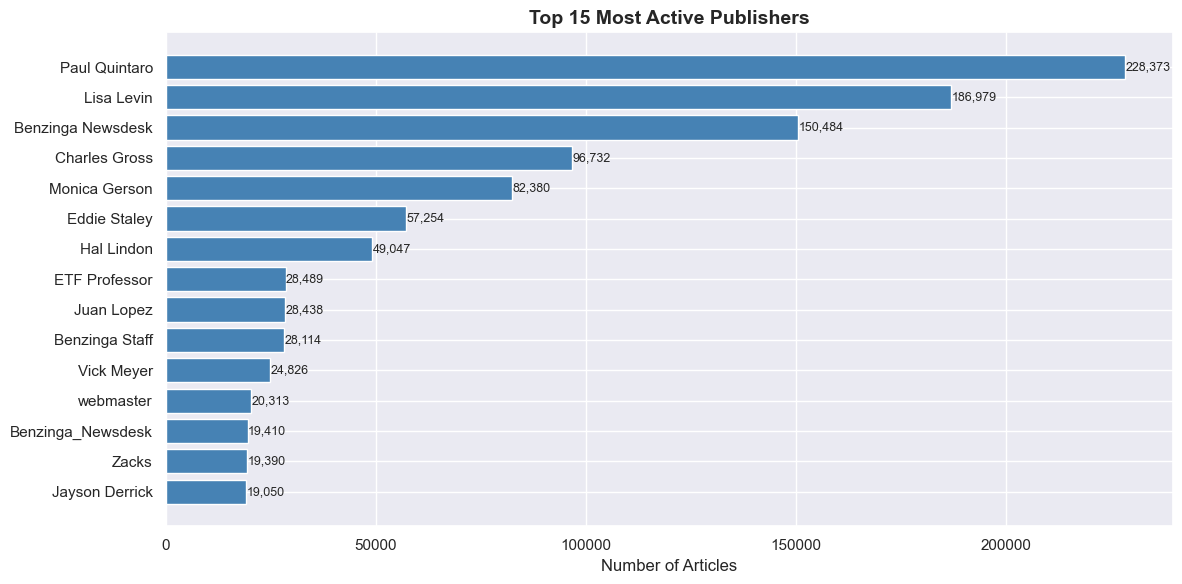

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


In [10]:
# Top publishers
publisher_counts = df['publisher'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
top_publishers = publisher_counts.head(15)
bars = ax.barh(top_publishers.index[::-1], top_publishers.values[::-1], color='steelblue')

for bar, val in zip(bars, top_publishers.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 15 Most Active Publishers', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Articles')
plt.tight_layout()
plt.show()
print(publisher_counts.head(10))

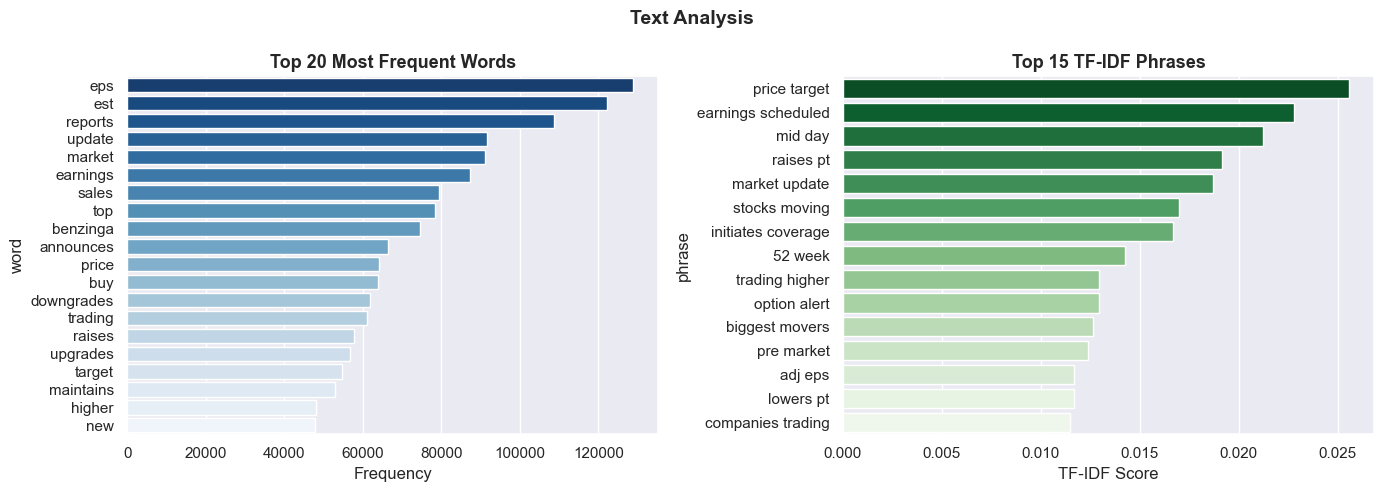

In [11]:
# Top keywords and TF-IDF phrases
stop_words = set(stopwords.words('english'))
stop_words.update({'stock', 'stocks', 'share', 'shares', 'company', 'inc', 'corp', 'ltd'})

def get_tokens(text):
    tokens = word_tokenize(str(text).lower())
    return [t for t in tokens if t.isalpha() and t not in stop_words and len(t) > 2]

all_tokens = []
for headline in df['headline']:
    all_tokens.extend(get_tokens(headline))

word_freq = Counter(all_tokens)
top_words = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top words
sns.barplot(data=top_words, x='count', y='word', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 20 Most Frequent Words', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

# TF-IDF
tfidf = TfidfVectorizer(max_features=50, ngram_range=(2, 3), stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['headline'].dropna())
tfidf_scores = pd.DataFrame({
    'phrase': tfidf.get_feature_names_out(),
    'score': tfidf_matrix.mean(axis=0).A1
}).sort_values('score', ascending=False).head(15)

sns.barplot(data=tfidf_scores, x='score', y='phrase', palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 15 TF-IDF Phrases', fontsize=13, fontweight='bold')
axes[1].set_xlabel('TF-IDF Score')

plt.suptitle('Text Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

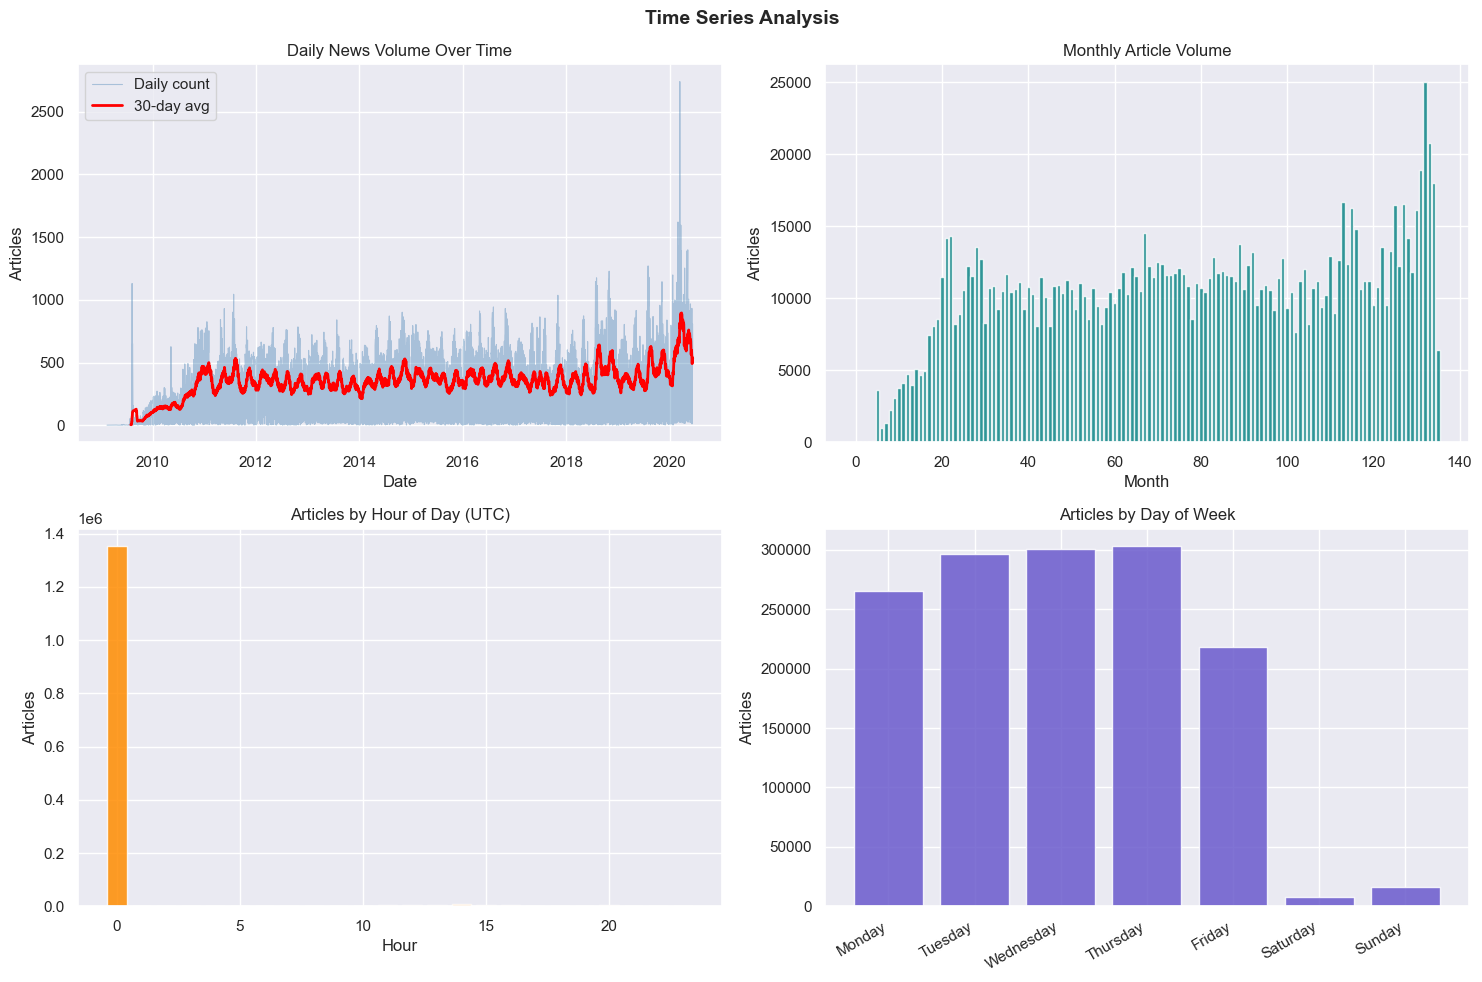

In [13]:
# Fix date column first
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)

# Time series - daily volume
df['date_only'] = df['date'].dt.normalize()
daily_counts = df.groupby('date_only').size().reset_index(name='article_count')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Daily volume
axes[0,0].plot(daily_counts['date_only'], daily_counts['article_count'], alpha=0.4, color='steelblue', linewidth=0.8, label='Daily count')
rolling = daily_counts.set_index('date_only')['article_count'].rolling(30).mean()
axes[0,0].plot(rolling.index, rolling.values, color='red', linewidth=2, label='30-day avg')
axes[0,0].set_title('Daily News Volume Over Time')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Articles')
axes[0,0].legend()

# Monthly volume
df['year_month'] = df['date'].dt.to_period('M')
monthly_counts = df.groupby('year_month').size()
axes[0,1].bar(range(len(monthly_counts)), monthly_counts.values, color='teal', alpha=0.8)
axes[0,1].set_title('Monthly Article Volume')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Articles')

# Hour of day
df['hour'] = df['date'].dt.hour
hour_counts = df['hour'].value_counts().sort_index()
axes[1,0].bar(hour_counts.index, hour_counts.values, color='darkorange', alpha=0.85)
axes[1,0].set_title('Articles by Hour of Day (UTC)')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Articles')

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df['date'].dt.day_name().value_counts().reindex(day_order)
axes[1,1].bar(range(7), dow_counts.values, color='slateblue', alpha=0.85)
axes[1,1].set_xticks(range(7))
axes[1,1].set_xticklabels(day_order, rotation=30, ha='right')
axes[1,1].set_title('Articles by Day of Week')
axes[1,1].set_ylabel('Articles')

plt.suptitle('Time Series Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

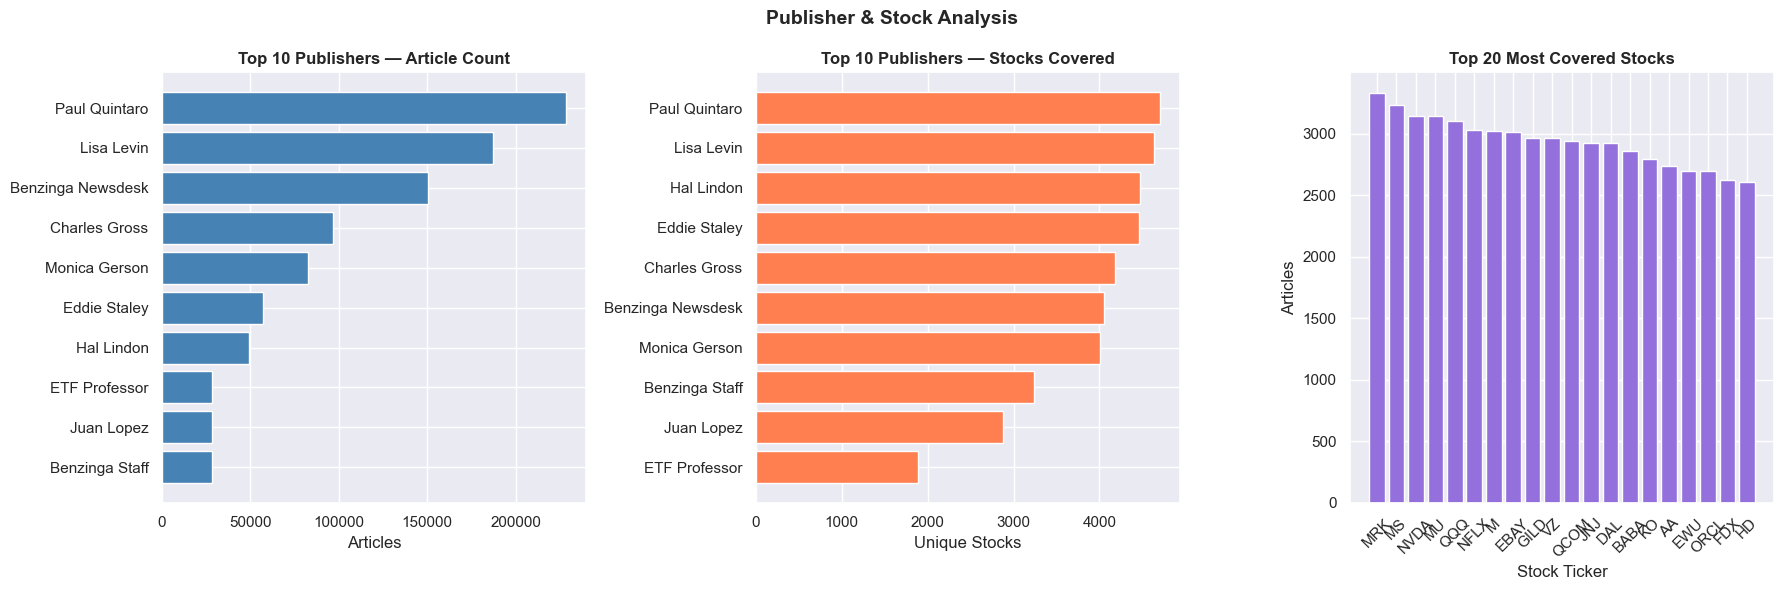

In [15]:
# Publisher analysis
top10_publishers = publisher_counts.head(10).index.tolist()
pub_stock_coverage = (
    df[df['publisher'].isin(top10_publishers)]
    .groupby('publisher')['stock']
    .nunique()
    .sort_values(ascending=False)
)

top_stocks = df['stock'].value_counts().head(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Article count per publisher
top10_counts = publisher_counts.head(10)
axes[0].barh(top10_counts.index[::-1], top10_counts.values[::-1], color='steelblue')
axes[0].set_title('Top 10 Publishers — Article Count', fontweight='bold')
axes[0].set_xlabel('Articles')

# Stock coverage per publisher
axes[1].barh(pub_stock_coverage.index[::-1], pub_stock_coverage.values[::-1], color='coral')
axes[1].set_title('Top 10 Publishers — Stocks Covered', fontweight='bold')
axes[1].set_xlabel('Unique Stocks')

# Most covered stocks
axes[2].bar(top_stocks.index, top_stocks.values, color='mediumpurple')
axes[2].set_title('Top 20 Most Covered Stocks', fontweight='bold')
axes[2].set_xlabel('Stock Ticker')
axes[2].set_ylabel('Articles')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Publisher & Stock Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()